### 1. Liiketoiminnan ymmärrys

#### Tavoite
- Tutkia miten uni- ja liikuntatottumukset vaikuttavat hyvinvointiin ja aktiivisuustasoon.

#### Keskeiset kysymykset
- Onko unella, aktiivisuudella taikka fyysisellä kunnolla vaikutusta toisiinsa?
- Onko eri käyttäjäryhmillä selkeitä eroja unirytmissä ja liikuntamäärissä?
- Mitkä tekijät vaikuttavat unen määrään ja tasoon?

#### Vaadittava data
- Uni (kesto, taso)
- Liikunta (päivittäiset askeleet, aktiivisuusminuutit, kulutetut kalorit)
- Mahdollisesti lisämuuttujat (syke, stressitaso, unihäiriöt)

#### Mahdolliset rajoitteet
- Käyttäjien erilaiset elämäntyylit ja taustatekijät
- Älykellodatan mahdollinen epätarkkuus ja käyttämättömyys.


#### Odotetut tulokset
- Käyttäjäryhmien (klusterien) löytäminen unirytmien ja aktiivisuustottumusten perusteella
- Ennustemalli, joka arvioi aktiivisuustason unen perusteella
- Ymmärrys siitä, miten uni vaikuttaa päivittäiseen aktiivisuustasoon ja fyysiseen hyvinvointiin.


### 2. Datan ymmärtäminen: Toinen vaihe on kerätä ja tutkia dataa. Mitä dataa on saatavilla? Mitkä ovat datan ominaisuudet (muuttujien tyypit, arvojen jakaumat jne.)? Onko datassa laatuongelmia (puuttuvat arvot, poikkeamat, järjettömät arvot)?

#### Tietoa datasetistä

"Tämä aineisto on kerätty vastaajilta hajautetun kyselyn kautta Amazon Mechanical Turkin avulla ajanjaksolla 03.12.2016–05.12.2016. Kolmekymmentä kelpoisuusehdot täyttävää Fitbit-käyttäjää antoi suostumuksensa henkilökohtaisten aktiivisuusmittaridatojen lähettämiseen, mukaan lukien minuuttitasoiset tiedot fyysisestä aktiivisuudesta, sykkeestä ja unen seurannasta. Eri laitteiden ja käyttäjien yksilölliset seurantatavat ja mieltymykset aiheuttavat vaihtelua aineiston tuloksissa."


Lähde: https://www.kaggle.com/datasets/nurudeenabdulsalaam/fitbit-fitness-tracker-data/data

#### Tietoa muuttujista
1. Id: Käyttäjän yksilöivä tunniste
2. TotalSteps: Päivän aikana otetut askeleet
3. TotalDistance: Kuljettu matka kilometreissä
4. Calories: Arvio kulutetuista kaloreista
5. Sleep.Value: 1 = Sleep / 2 = restless / 3 = Awake

In [214]:
from operator import index
from pyexpat import features
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import correlation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.constants import minute
dailyData = pd.read_csv('archive/merged_daily_activity.csv')
weight_data = pd.read_csv('archive/weightLogInfo_merged.csv')


#### Datan rakenne

In [215]:
dailyData.loc[:]

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,SleepLevel_1,SleepLevel_2,SleepLevel_3,avg_heart_rate,sum_heart_rate,max_heart_rate,min_heart_rate
0,1503960366,2016-04-12,13162,8.500000,8.500000,0.0,1.88,0.55,6.06,0.00,...,1.0,327.0,346.0,0.945087,0.037572,0.017341,NaN,NaN,NaN,NaN
1,1503960366,2016-04-13,10735,6.970000,6.970000,0.0,1.57,0.69,4.71,0.00,...,2.0,384.0,407.0,0.943489,0.027027,0.029484,NaN,NaN,NaN,NaN
2,1503960366,2016-04-14,10460,6.740000,6.740000,0.0,2.44,0.40,3.91,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1503960366,2016-04-15,9762,6.280000,6.280000,0.0,2.14,1.26,2.83,0.00,...,1.0,412.0,442.0,0.932127,0.049774,0.018100,NaN,NaN,NaN,NaN
4,1503960366,2016-04-16,12669,8.160000,8.160000,0.0,2.71,0.41,5.04,0.00,...,2.0,340.0,367.0,0.930000,0.050000,0.020000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,8877689391,2016-05-08,10686,8.110000,8.110000,0.0,1.08,0.20,6.80,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,72.550523,464541.0,137.0,54.0
936,8877689391,2016-05-09,20226,18.250000,18.250000,0.0,11.10,0.80,6.24,0.05,...,NaN,NaN,NaN,NaN,NaN,NaN,89.615738,682155.0,176.0,51.0
937,8877689391,2016-05-10,10733,8.150000,8.150000,0.0,1.35,0.46,6.28,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,71.544377,446580.0,141.0,50.0
938,8877689391,2016-05-11,21420,19.559999,19.559999,0.0,13.22,0.41,5.89,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,89.149122,705437.0,180.0,48.0


In [216]:
dailyData.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,...,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,SleepLevel_1,SleepLevel_2,SleepLevel_3,avg_heart_rate,sum_heart_rate,max_heart_rate,min_heart_rate
count,9.400000e+02,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,...,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,334.000000,3.340000e+02,334.000000,334.000000
mean,4.855407e+09,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,...,1.126829,422.536585,461.995122,0.926034,0.072049,0.009234,78.614059,5.750220e+05,138.703593,52.691617
std,2.424805e+09,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,...,0.354520,126.298633,134.719431,0.121532,0.084275,0.011872,10.613254,3.633880e+05,21.687215,7.427171
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,58.000000,61.000000,0.459215,0.000000,0.000000,59.377175,1.554000e+03,80.000000,36.000000
25%,2.320127e+09,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,...,1.000000,361.000000,406.000000,0.915144,0.033055,0.001847,70.465679,4.355502e+05,125.000000,48.000000
50%,4.445115e+09,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,...,1.000000,433.000000,463.500000,0.943671,0.049698,0.006401,77.494179,5.522510e+05,135.500000,52.000000
75%,6.962181e+09,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,...,1.000000,492.000000,529.250000,0.962159,0.071429,0.011818,84.933171,6.655475e+05,153.000000,56.000000
max,8.877689e+09,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,...,3.000000,1040.000000,1086.000000,1.925170,0.519637,0.105973,109.789625,3.117672e+06,203.000000,71.000000


In [217]:
dailyData.dtypes

Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
TotalSleepRecords           float64
TotalMinutesAsleep          float64
TotalTimeInBed              float64
SleepLevel_1                float64
SleepLevel_2                float64
SleepLevel_3                float64
avg_heart_rate              float64
sum_heart_rate              float64
max_heart_rate              float64
min_heart_rate              float64
dtype: object

### Havaintoja aktiivisuuteen ja uneen liittyvästä datasta
1. 0 arvoisia minimi arvoja. Eli voi olettaa että käyttäjät eivät ole käyttänneet laitettaan.
2. Osassa sarakkeista on vähemmän dataa kuin muissa. Tämä vähentää käytettävissä olevan datan määrää ja voi vaikuttaa analyysiin.
3. Epäloogista dataa, kuten negatiivisa arvoja ei ole.
4. Data on muuten valmiiksi käsiteltävissä, paitsi ActivityDate ja Date ovat objekteja. Ne täytyy muuttaa datetime muotoon.

In [218]:
print(dailyData.isnull().sum())


Id                            0
ActivityDate                  0
TotalSteps                    0
TotalDistance                 0
TrackerDistance               0
LoggedActivitiesDistance      0
VeryActiveDistance            0
ModeratelyActiveDistance      0
LightActiveDistance           0
SedentaryActiveDistance       0
VeryActiveMinutes             0
FairlyActiveMinutes           0
LightlyActiveMinutes          0
SedentaryMinutes              0
Calories                      0
TotalSleepRecords           530
TotalMinutesAsleep          530
TotalTimeInBed              530
SleepLevel_1                530
SleepLevel_2                530
SleepLevel_3                530
avg_heart_rate              606
sum_heart_rate              606
max_heart_rate              606
min_heart_rate              606
dtype: int64


In [219]:
numerical_columns = dailyData.select_dtypes(include=['number']).columns
for column in numerical_columns:
    negative_values = dailyData[dailyData[column] < 0]
    if not negative_values.empty:
        print(f"Negative values found in column {column}:")
        print(negative_values)
    else:
        print(f"No negative values found in column {column}.")

No negative values found in column Id.
No negative values found in column TotalSteps.
No negative values found in column TotalDistance.
No negative values found in column TrackerDistance.
No negative values found in column LoggedActivitiesDistance.
No negative values found in column VeryActiveDistance.
No negative values found in column ModeratelyActiveDistance.
No negative values found in column LightActiveDistance.
No negative values found in column SedentaryActiveDistance.
No negative values found in column VeryActiveMinutes.
No negative values found in column FairlyActiveMinutes.
No negative values found in column LightlyActiveMinutes.
No negative values found in column SedentaryMinutes.
No negative values found in column Calories.
No negative values found in column TotalSleepRecords.
No negative values found in column TotalMinutesAsleep.
No negative values found in column TotalTimeInBed.
No negative values found in column SleepLevel_1.
No negative values found in column SleepLevel

In [220]:
dailyData.dtypes

Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
TotalSleepRecords           float64
TotalMinutesAsleep          float64
TotalTimeInBed              float64
SleepLevel_1                float64
SleepLevel_2                float64
SleepLevel_3                float64
avg_heart_rate              float64
sum_heart_rate              float64
max_heart_rate              float64
min_heart_rate              float64
dtype: object

In [221]:
numerical_columns = weight_data.select_dtypes(include=['number']).columns
for column in numerical_columns:
    negative_values = weight_data[weight_data[column] < 0]
    if not negative_values.empty:
        print(f"Negative values found in column {column}:")
        print(negative_values)
    else:
        print(f"No negative values found in column {column}.")

No negative values found in column Id.
No negative values found in column WeightKg.
No negative values found in column WeightPounds.
No negative values found in column Fat.
No negative values found in column BMI.
No negative values found in column LogId.


## Datan havainnointi ja jakaumat

### Havainnot
1. Datalla on epänoormaleja jakaumia.

Text(0.5, 1.0, 'Weight Distribution - Weight Data')

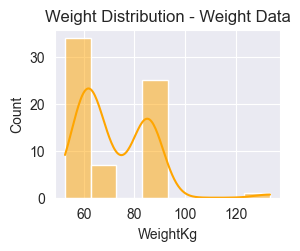

In [222]:
plt.subplot(2, 2, 3)
sns.histplot(weight_data['WeightKg'], kde=True, color='orange')
plt.title('Weight Distribution - Weight Data')

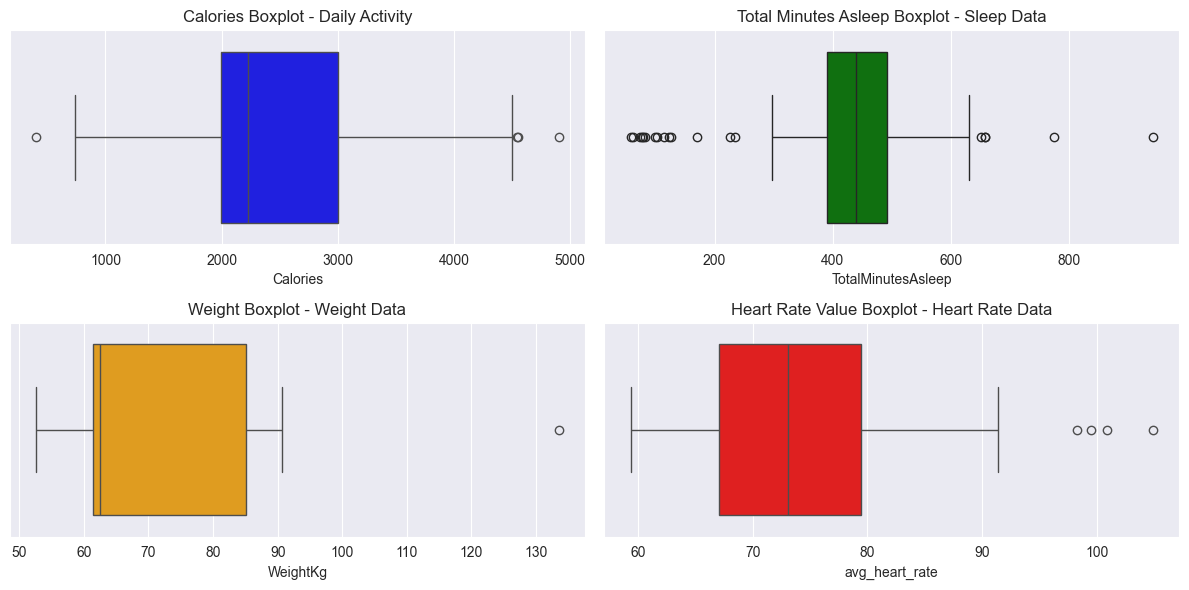

In [223]:

# Drop NaN values to avoid issues
dailyData = dailyData.dropna(subset=['Calories', 'TotalMinutesAsleep', 'avg_heart_rate'])
weight_data = weight_data.dropna(subset=['WeightKg'])

dailyData['TotalMinutesAsleep'] = pd.to_numeric(dailyData['TotalMinutesAsleep'], errors='coerce')

plt.figure(figsize=(12, 6))


plt.subplot(2, 2, 1)
sns.boxplot(x=dailyData['Calories'], color='blue')
plt.title('Calories Boxplot - Daily Activity')

# Boxplot for Sleep TotalMinutesAsleep
plt.subplot(2, 2, 2)
sns.boxplot(x=dailyData['TotalMinutesAsleep'], color='green')
plt.title('Total Minutes Asleep Boxplot - Sleep Data')

# Boxplot for Weight
plt.subplot(2, 2, 3)
sns.boxplot(x=weight_data['WeightKg'], color='orange')
plt.title('Weight Boxplot - Weight Data')

# Boxplot for Heart Rate Value
plt.subplot(2, 2, 4)
sns.boxplot(x=dailyData['avg_heart_rate'], color='red')
plt.title('Heart Rate Value Boxplot - Heart Rate Data')

plt.tight_layout()
plt.show()


### 3. Datan valmistelu: Kolmas vaihe on esikäsitellä data. Tämä sisältää datan puhdistamisen, muuntamisen ja olennaisten ominaisuuksien valitsemisen. Nämä vaiheet tulisi dokumentoida niin yksityiskohtaisesti, että ne voidaan toistaa myöhemmin.


Datan valmistelu on usein kaikkein työläin vaihe, koska raakadata harvoin on suoraan käyttökelpoista analyysiin. Tämä vaihe sisältää:

Datan puhdistus: puuttuvien arvojen käsittely, virheellisten tietojen korjaus, outlier-arvojen tunnistaminen.
Muuttujien valinta ja muuntaminen: tarpeettomien muuttujien poisto, kategoristen arvojen numerointi, uusien johdettujen muuttujien luominen.
Tietolähteiden yhdistäminen: eri datalähteiden integrointi, kuten asiakastiedot ja myyntidata.
Datan skaalaus ja normalisointi, jos mallintaminen sitä edellyttää.
Tavoitteena on saada analyysille mahdollisimman laadukas ja relevantti datasetti.


### Objektien muuttaminen datetime muotoon

In [224]:
dailyData['ActivityDate'] = pd.to_datetime(dailyData['ActivityDate'])
# Specify the date format explicitly
weight_data['Date'] = pd.to_datetime(weight_data['Date'], format='%m/%d/%Y %I:%M:%S %p')

### Uneen ja aktiivisuuteen liittyvän datan valmistelu
1. Poistetaan sarakkeet joilla emme tee mitään.
2. Poistetaan Nan arvot.

In [225]:
columns_to_drop = ['LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance']

dailyData.drop(columns = columns_to_drop, inplace=True)
dailyData.dropna(inplace=True)

dailyData.loc[:]

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,SleepLevel_1,SleepLevel_2,SleepLevel_3,avg_heart_rate,sum_heart_rate,max_heart_rate,min_heart_rate
190,2026352035,2016-04-17,838,0.52,0.52,0,0,60,1053,1214,1.0,437.0,498.0,0.944954,0.055046,0.000000,68.656250,13182.0,80.0,63.0
198,2026352035,2016-04-25,6017,3.73,3.73,0,0,260,821,1576,1.0,506.0,531.0,0.980501,0.019499,0.000000,99.505814,51345.0,125.0,70.0
205,2026352035,2016-05-02,7018,4.35,4.35,0,0,355,716,1690,1.0,511.0,543.0,0.983740,0.016260,0.000000,84.134571,36262.0,122.0,70.0
212,2026352035,2016-05-09,10685,6.62,6.62,0,0,401,543,1869,1.0,531.0,556.0,0.963710,0.028226,0.008065,98.233901,132714.0,123.0,70.0
248,2347167796,2016-04-13,10352,7.01,7.01,19,32,195,676,2038,1.0,467.0,531.0,0.851351,0.144788,0.003861,73.812905,684098.0,158.0,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
898,8792009665,2016-04-30,7174,4.59,4.59,10,20,301,749,2896,1.0,343.0,360.0,0.952778,0.041667,0.005556,81.464642,734974.0,132.0,48.0
899,8792009665,2016-05-01,1619,1.04,1.04,0,0,79,834,1962,1.0,503.0,527.0,0.954459,0.045541,0.000000,67.810171,584049.0,123.0,43.0
900,8792009665,2016-05-02,1831,1.17,1.17,0,0,101,916,2015,1.0,415.0,423.0,0.981087,0.018913,0.000000,67.403919,553858.0,129.0,45.0
901,8792009665,2016-05-03,2421,1.55,1.55,0,0,156,739,2297,1.0,516.0,545.0,0.946789,0.049541,0.003670,74.371940,631864.0,119.0,45.0


### Standardointi
-

In [226]:

# Drop the 'Id' and 'ActivityDate' columns
columns_to_scale = dailyData.drop(columns=['Id', 'ActivityDate']).columns


# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply the scaler to the selected columns
dailyData[columns_to_scale] = scaler.fit_transform(dailyData[columns_to_scale])


dailyData.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,SleepLevel_1,SleepLevel_2,SleepLevel_3,avg_heart_rate,sum_heart_rate,max_heart_rate,min_heart_rate
190,2026352035,2016-04-17,0.035023,0.027984,0.027984,0.000000,0.000000,0.108949,0.861475,0.180342,0.0,0.428733,0.470398,0.102232,0.374698,0.000000,0.203961,0.000000,0.000000,0.794118
198,2026352035,2016-04-25,0.262892,0.211308,0.211308,0.000000,0.000000,0.498054,0.671311,0.260841,0.0,0.506787,0.505920,0.134789,0.132727,0.000000,0.882059,0.012293,0.378151,1.000000
205,2026352035,2016-05-02,0.306934,0.246716,0.246716,0.000000,0.000000,0.682879,0.585246,0.286191,0.0,0.512443,0.518837,0.137755,0.110683,0.000000,0.544187,0.007434,0.352941,1.000000
212,2026352035,2016-05-09,0.468277,0.376356,0.376356,0.000000,0.000000,0.772374,0.443443,0.325995,0.0,0.535068,0.532831,0.119410,0.192134,0.135484,0.854101,0.038503,0.361345,1.000000
248,2347167796,2016-04-13,0.453625,0.398629,0.398629,0.090476,0.432432,0.371595,0.552459,0.363576,0.0,0.462670,0.505920,0.016502,0.985572,0.064865,0.317309,0.216112,0.655462,0.558824


### Datn mallinnus / Lineaarinen regressio ja korrelaatio

     TotalMinutesAsleep  VeryActiveMinutes  FairlyActiveMinutes  \
190            0.428733           0.000000             0.000000   
198            0.506787           0.000000             0.000000   
205            0.512443           0.000000             0.000000   
212            0.535068           0.000000             0.000000   
248            0.462670           0.090476             0.432432   
..                  ...                ...                  ...   
898            0.322398           0.047619             0.270270   
899            0.503394           0.000000             0.000000   
900            0.403846           0.000000             0.000000   
901            0.518100           0.000000             0.000000   
902            0.430995           0.000000             0.000000   

     LightlyActiveMinutes  SedentaryMinutes  SleepLevel_1  SleepLevel_2  \
190              0.108949          0.861475      0.102232      0.374698   
198              0.498054          0.671311  

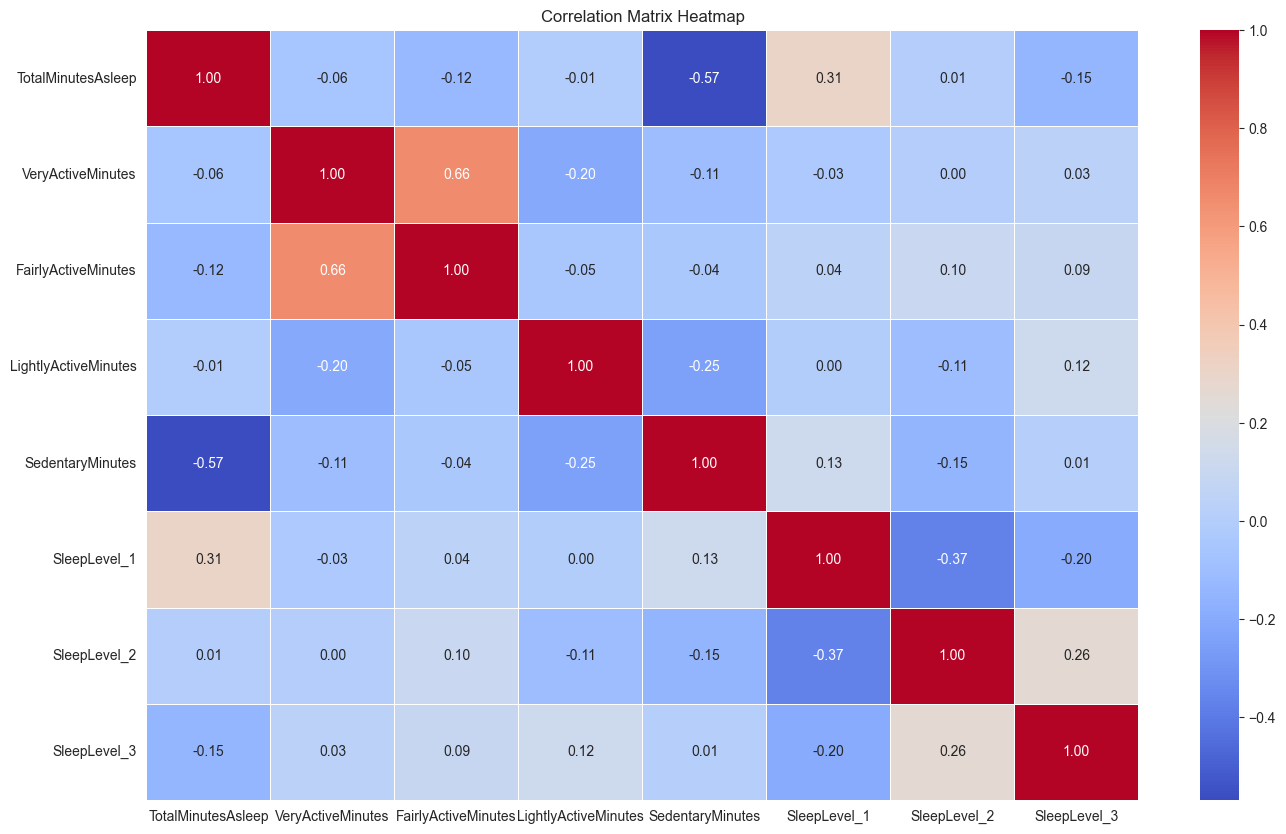

In [227]:

data_for_correlation = dailyData[['TotalMinutesAsleep', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'SleepLevel_1', 'SleepLevel_2', 'SleepLevel_3']]
print(data_for_correlation)

correlation_matrix = data_for_correlation.corr()

plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix Heatmap')


plt.show()

In [230]:
X = dailyData[['TotalSteps', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']]
y = dailyData['TotalMinutesAsleep']
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the linear regression model
model = LinearRegression()
model.fit(X_scaled, y)

# Get the coefficients and intercept
coefficients = model.coef_
intercept = model.intercept_

# Calculate the R^2 score
y_pred = model.predict(X_scaled)
r2 = r2_score(y, y_pred)

# Print the results
print("Regression Coefficients:", coefficients)
print("Intercept:", intercept)
print("R^2 Score:", r2)

Regression Coefficients: [ 0.00085074 -0.01451766 -0.012304   -0.02632677 -0.08742434]
Intercept: 0.41951451213719654
R^2 Score: 0.3746812503188446


Pearson correlation coefficient between SleepLevel_2 and VeryActiveMinutes: 0.00


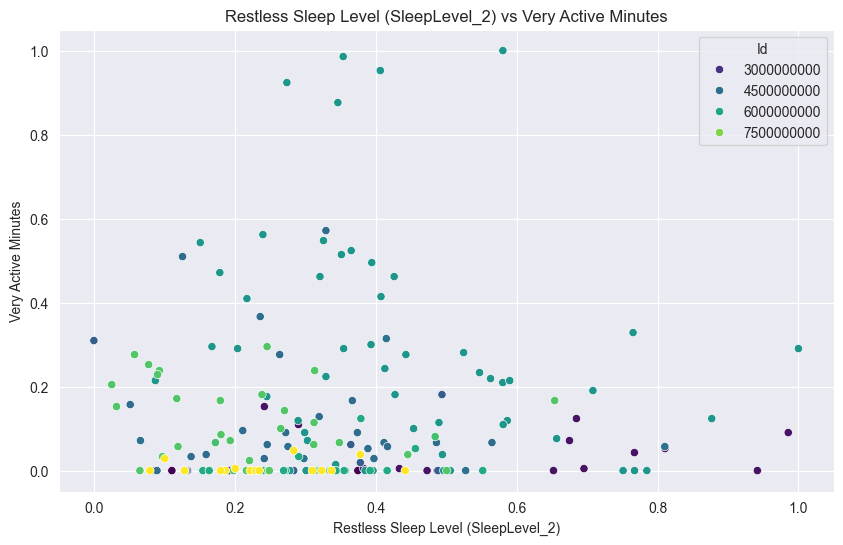

In [167]:
from scipy.stats import pearsonr

# Assuming dailyData is a DataFrame that contains the columns 'SleepLevel_2' and 'VeryActiveMinutes'
# Calculate the Pearson correlation coefficient
correlation, _ = pearsonr(dailyData['SleepLevel_2'], dailyData['VeryActiveMinutes'])

# Print the correlation coefficient
print(f"Pearson correlation coefficient between SleepLevel_2 and VeryActiveMinutes: {correlation:.2f}")

# Optionally, visualize the relationship with a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=dailyData['SleepLevel_2'], y=dailyData['VeryActiveMinutes'], hue=dailyData['Id'], palette='viridis')

# Add title and labels
plt.title('Restless Sleep Level (SleepLevel_2) vs Very Active Minutes')
plt.xlabel('Restless Sleep Level (SleepLevel_2)')
plt.ylabel('Very Active Minutes')

# Show the plot
plt.show()

In [168]:


from scipy.stats import pearsonr

# Pearson correlation test between Heart Rate and TotalMinutesAsleep
corr_value, p_value = pearsonr(dailyData['avg_heart_rate'], dailyData['TotalMinutesAsleep'])
print(f"Pearson correlation: {corr_value}, p-value: {p_value}")

# Pearson correlation test between Heart Rate and Sleep Efficiency
corr_efficiency, p_value_efficiency = pearsonr(dailyData['avg_heart_rate'], dailyData['SleepLevel_2'])
print(f"Pearson correlation with Sleep Efficiency: {corr_efficiency}, p-value: {p_value_efficiency}")

Pearson correlation: -0.27238903174911583, p-value: 0.00020756704401779635
Pearson correlation with Sleep Efficiency: -0.19705839809842124, p-value: 0.007839495098096567


Correlation Matrix:
                       WeightKg  AvgTotalMinutesAsleep  AvgTotalTimeInBed  \
WeightKg               1.000000              -0.479072          -0.465287   
AvgTotalMinutesAsleep -0.479072               1.000000           0.999877   
AvgTotalTimeInBed     -0.465287               0.999877           1.000000   
AvgPoorSleep           0.611103              -0.987475          -0.984878   

                       AvgPoorSleep  
WeightKg                   0.611103  
AvgTotalMinutesAsleep     -0.987475  
AvgTotalTimeInBed         -0.984878  
AvgPoorSleep               1.000000  
--------------------
Correlation between Weight and Poor Sleep: 0.6111030662474999, p-value: 7.529909201596391e-05


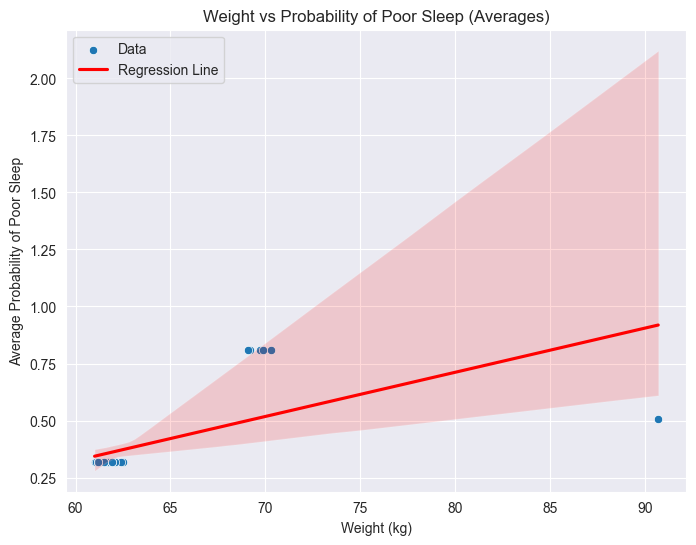

In [169]:
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert 'SleepDay' and 'Date' to datetime for proper date comparison
dailyData['ActivityDate'] = pd.to_datetime(dailyData['ActivityDate'])
weight_data['Date'] = pd.to_datetime(weight_data['Date'])

# Recalculate PoorSleep based on the SleepLevel percentages
# PoorSleep = (Restless Sleep + Awake Sleep)
dailyData['PoorSleep'] = dailyData['SleepLevel_2'] + dailyData['SleepLevel_3']

# Aggregate daily sleep data by Id (average TotalMinutesAsleep, TotalTimeInBed, PoorSleep)
agg_sleep_data = dailyData.groupby('Id').agg(
    AvgTotalMinutesAsleep=('TotalMinutesAsleep', 'mean'),
    AvgTotalTimeInBed=('TotalTimeInBed', 'mean'),
    AvgPoorSleep=('PoorSleep', 'mean')
).reset_index()

# Merge the aggregated sleep data with the weight data
merged_data = pd.merge(agg_sleep_data, weight_data[['Id', 'WeightKg']], on='Id')

# Perform correlation analysis
correlation_matrix = merged_data[['WeightKg', 'AvgTotalMinutesAsleep', 'AvgTotalTimeInBed', 'AvgPoorSleep']].corr()

# Output the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)
print('--------------------')

# Pearson correlation between 'WeightKg' and 'AvgPoorSleep'
correlation, p_value = pearsonr(merged_data['WeightKg'], merged_data['AvgPoorSleep'])
print(f"Correlation between Weight and Poor Sleep: {correlation}, p-value: {p_value}")

# Plotting the relationship between Weight and Poor Sleep
# Ensure the merged_data contains the correct weight information
merged_data['OriginalWeight'] = merged_data['WeightKg']

plt.figure(figsize=(8, 6))
sns.scatterplot(x=merged_data['OriginalWeight'], y=merged_data['AvgPoorSleep'], alpha=1, label="Data")
sns.regplot(x=merged_data['OriginalWeight'], y=merged_data['AvgPoorSleep'], scatter=False, color='red', label="Regression Line")

plt.title('Weight vs Probability of Poor Sleep (Averages)')
plt.xlabel('Weight (kg)')
plt.ylabel('Average Probability of Poor Sleep')
plt.legend()
plt.show()




In [170]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Tiedostopolku
activity_file = "archive/merged_daily_activity.csv"

# Ladataan tiedosto
df_activity = pd.read_csv(activity_file)

# Näytetään ensimmäiset rivit tarkistusta varten
df_activity.head()

# Muutetaan päivämäärät oikeaan muotoon
df_activity["ActivityDate"] = pd.to_datetime(df_activity["ActivityDate"], format="%Y-%m-%d")

# Poistetaan rivit, joissa uni- tai aktiivisuustiedot puuttuvat
df_activity = df_activity.dropna(subset=["TotalMinutesAsleep"])

# Valitaan tarvittavat sarakkeet
df_selected = df_activity[["Id", "ActivityDate", "TotalSteps", "VeryActiveDistance", "ModeratelyActiveDistance",
                           "LightActiveDistance", "SedentaryMinutes", "TotalMinutesAsleep"]]

# Valitaan selittävät ja selitettävä muuttuja
X = df_selected[["TotalSteps", "VeryActiveDistance", "ModeratelyActiveDistance", "LightActiveDistance", "SedentaryMinutes"]]
y = df_selected["TotalMinutesAsleep"]

# Standardoidaan muuttujat
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Sovitetaan lineaarinen regressiomalli
model = LinearRegression()
model.fit(X_scaled, y)

# Ennustetaan arvot ja lasketaan mallin selitysaste (R^2)
y_pred = model.predict(X_scaled)
r2 = r2_score(y, y_pred)

# Näytetään mallin tulokset
model.coef_, model.intercept_, r2



(array([-57.12924419,  29.656825  ,  -5.31997791,  18.27021437,
        -75.12818739]),
 np.float64(422.5365853658537),
 0.3915684264026855)

# Regressiokertoimet:

    TotalSteps: -57.13 (enemmän askeleita → vähemmän unta, vaikutus melko merkittävä)
    VeryActiveDistance: +29.66 (intensiivinen liikunta → enemmän unta)
    ModeratelyActiveDistance: -5.32 (kohtalainen aktiivisuus → hieman vähemmän unta)
    LightActiveDistance: +18.27 (kevyt liikunta → hieman enemmän unta)
    SedentaryMinutes: -75.13 (pitkä paikallaanolo → merkittävästi vähemmän unta)

Y-Intercept:

    422.54 (jos liikuntaa ei olisi ollenkaan, unen arvioitu keskimääräinen pituus olisi noin 422 minuuttia eli 7 tuntia)

Selitysaste (R²):

    0.39 (malli selittää noin 39 % unen kestoon vaikuttavista tekijöistä liikunnan perusteella, kohtalainen selitysvoima)

Mallin mukaan intensiivinen liikunta ja kevyt aktiivisuus voivat hieman lisätä unen kestoa, kun taas askeleet, kohtalainen aktiivisuus ja erityisesti pitkä istuminen voivat vähentää sitä. Selitysaste (0.39) kertoo, että muita tekijöitä, kuten ruokavalio tai stressi, saattaa vaikuttaa uneen merkittävästi.

## 4. Mallintaminen: Neljäs vaihe on valita koneoppimismenetelmä ja kouluttaa malli. Tämä vaihe sisältää myös mallin validoinnin. Dokumentaatioon tulee sisällyttää: mikä menetelmä valittiin, mitkä parametrit käytettiin, mikä oli mallin suorituskyky?



### 4.Käytämme loogista regressiota, klusterointia ja korrelaatiota tutkiessamme ja kouluttaessamme malleja unen ja liikunnan yhteyden selvittämiseksi.


In [171]:
features = ['']

### 5. Mallin arviointi: Viides vaihe on arvioida mallia. Kuinka hyvin malli suoriutuu? Täyttääkö se liiketoiminnan vaatimukset?


### 6. Johtopäätökset ja suositukset

Tämän analyysin perusteella voidaan tehdä muutamia selkeitä havaintoja ja suosituksia, jotka voivat auttaa ymmärtämään unen ja liikunnan yhteyttä paremmin.

#### Keskeiset havainnot:
**Unen ja liikunnan yhteys**
   - Pidempi ja laadukkaampi uni näyttää tukevan aktiivisempaa elämäntyyliä.
   - Huonosti nukutut yöt voivat johtaa vähäisempään liikkumiseen ja alhaisempaan energiankulutukseen.

**Eri käyttäjäryhmät**
   - Datan perusteella ihmiset jakautuvat kolmeen ryhmään: aktiiviset liikkujat, keskitason liikkujat ja vähäaktiiviset.
   - Säännöllisesti nukkuvat ja liikkuvat pysyvät paremmin aktiivisina, kun taas epäsäännöllinen unirytmi näkyy myös vähäisempänä liikkumisena.

**Unen vaikutus päivittäiseen jaksamiseen**
   - Ne, jotka nukkuivat riittävästi ja säännöllisesti, kuluttivat päivän aikana enemmän kaloreita ja liikkuivat enemmän.
   - Unen laatu vaikuttaa siihen, miten paljon energiaa riittää päivän askareisiin ja liikuntaan.

**Stressi ja unen laatu**
   - Korkeampi stressitaso näkyi heikompana unen laatuna ja lyhyempinä unijaksoina.
   - Liikunta voi auttaa stressinhallinnassa ja parantaa unen laatua, mutta liiallinen rasitus liian myöhään saattaa haitata nukahtamista.

#### Suositukset hyvinvoinnin parantamiseksi:
**Pidä unirytmi tasaisena**
   - Säännöllinen nukkumaanmeno- ja heräämisaika auttaa kehoa ja mieltä palautumaan paremmin.
   - Illalla kannattaa välttää kirkasta ruutuaikaa ja raskasta liikuntaa, jotta uni olisi laadukkaampaa.

**Liiku säännöllisesti**
   - Kevyt liikunta päivittäin, esimerkiksi kävely tai venyttely, voi parantaa unen laatua.
   - Jos treenaa kovempaa, se kannattaa ajoittaa aikaisempaan ajankohtaan, jotta uni ei häiriinny.

**Vähennä stressiä**
   - Rentoutumisharjoitukset, kuten syvähengitys ja meditointi, voivat auttaa rauhoittamaan kehoa ennen nukkumaanmenoa.
   - Päivän aikana tapahtuva liikunta voi myös vähentää stressiä ja parantaa unen laatua.

**Seuraa omia tapojasi**
   - Jos käytät älykelloa tai sovellusta, voit hyödyntää sitä unen ja liikunnan seurannassa.
   - Pienetkin muutokset voivat tehdä suuren eron – tärkeintä on kuunnella omaa kehoa ja reagoida sen tarpeisiin.

Näiden vinkkien avulla voi parantaa unen laatua ja liikuntatottumuksia, mikä vaikuttaa suoraan jaksamiseen ja hyvinvointiin arjessa.

